# Unsupervised – Vectorization & clustering (patient testimonies)

This notebook builds and compares **unsupervised clustering pipelines** for the CVRIE testimonies dataset.

## Subject compliance reminders
- We do **not** add labels.
- We do **not** use the hidden `color` field for training.
- We use `color` **only** to color plots for the defense requirement.


In [1]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import Normalizer
from sklearn.pipeline import make_pipeline

from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

plt.style.use("seaborn-v0_8")

FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)


def save_current_fig(filename: str) -> None:
    path = FIG_DIR / filename
    plt.gcf().savefig(path, dpi=160, bbox_inches="tight")
    print(f"Saved: {path}")

CLEAN_PATH = Path("cleaned_unsupervised_dataset.csv")
# Robust CSV parsing (the testimonies may contain commas/quotes)
df = pd.read_csv(
    CLEAN_PATH,
    engine="python",
    quotechar='"',
    escapechar="\\",
    skipinitialspace=True,
)
df.shape, df.columns.tolist()


((995, 4), ['id', 'color', 'testimony_raw', 'testimony_clean'])

In [2]:
df.head()


,id,color,testimony_raw,testimony_clean
0,2,0x000000,"The feverish feeling eased, but I’m now breath...","the feverish feeling eased, but i'm now breath..."
1,3,0x000000,"While working in the garden, I touched a metal...","while working in the garden, i touched a metal..."
2,4,NaN,A short sprint brought on a twinge in the midd...,a short sprint brought on a twinge in the midd...
3,5,0x000000,I accidentally left my hand on a hot mug for a...,i accidentally left my hand on a hot mug for a...
4,6,NaN,A sudden twist while reaching for a bag made o...,a sudden twist while reaching for a bag made o...


## 1) Vectorization baselines

We compare feature extraction approaches using only sklearn tools (per subject constraints):
- **TF-IDF (uni+bi-grams)**: strong bag-of-words baseline for short medical texts
- **TF-IDF → TruncatedSVD (LSA) → normalization**: reduces sparsity/noise and makes clustering distances more stable


In [3]:
texts = df["testimony_clean"].astype(str).tolist()

tfidf = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.90,
)

X_tfidf = tfidf.fit_transform(texts)
X_tfidf.shape


(995, 2842)

In [4]:
SVD_DIMS = 100
lsa = make_pipeline(
    TruncatedSVD(n_components=SVD_DIMS, random_state=42),
    Normalizer(copy=False),
)
X_lsa = lsa.fit_transform(X_tfidf)
X_lsa.shape


(995, 100)

## 2) Clustering baselines

We try multiple clustering families (as required):
- **KMeans** (often strong for TF-IDF/LSA text features)
- **Agglomerative** (average linkage; applied on LSA features)
- **DBSCAN** (density-based; applied on LSA features)

Because we have no labels, we compare using multiple **unsupervised metrics** and qualitative inspection.


### Loss / objective (subject requirement)

Even in unsupervised learning, our model optimizes an objective.

- **KMeans “loss”**: it minimizes **inertia**, the sum of squared distances from each point to its assigned centroid:

  \[
  \text{inertia} = \sum_{i=1}^{n} \lVert x_i - \mu_{c(i)} \rVert^2
  \]

  where \(x_i\) is a sample (here: an LSA vector), \(c(i)\) is its cluster assignment, and \(\mu\) are the centroids.

- **Why we use TF‑IDF → LSA before KMeans**: TF‑IDF is high-dimensional and sparse; LSA (TruncatedSVD + normalization) produces a dense representation where Euclidean distances are more stable, making KMeans optimization and comparisons more meaningful.

- **We do not use hidden `color` for training**: it is only used to color plots for the defense.


In [5]:
@dataclass
class RunResult:
    name: str
    n_clusters: int
    noise_rate: float
    silhouette: float | None
    calinski_harabasz: float | None
    davies_bouldin: float | None
    top_cluster_sizes: list[int]


def _cluster_sizes(labels: np.ndarray) -> list[int]:
    valid = labels[labels >= 0]
    if valid.size == 0:
        return []
    return sorted(np.bincount(valid).tolist(), reverse=True)


def evaluate_unsupervised(
    X: Any,
    labels: np.ndarray,
    *,
    silhouette_metric: str,
) -> tuple[float | None, float | None, float | None]:
    unique = sorted(set(int(x) for x in labels.tolist() if int(x) != -1))
    if len(unique) < 2:
        return None, None, None

    sample_size = min(600, len(labels))
    sil = silhouette_score(
        X,
        labels,
        metric=silhouette_metric,
        sample_size=sample_size,
        random_state=42,
    )

    # CH/DB require a dense numeric array. For sparse TF-IDF matrices, we skip them
    # and rely on silhouette + the dense LSA runs for CH/DB comparisons.
    is_sparse = hasattr(X, "toarray") and not isinstance(X, np.ndarray)
    if is_sparse:
        return float(sil), None, None

    X_dense = np.asarray(X)
    ch = calinski_harabasz_score(X_dense, labels)
    db = davies_bouldin_score(X_dense, labels)
    return float(sil), float(ch), float(db)


def run_and_score(name: str, model: Any, X: Any, *, silhouette_metric: str) -> RunResult:
    labels = np.asarray(model.fit_predict(X))
    unique_all = sorted(set(int(x) for x in labels.tolist()))
    n_clusters = len([u for u in unique_all if u != -1])
    noise_rate = float(np.mean(labels == -1))
    sil, ch, db = evaluate_unsupervised(X, labels, silhouette_metric=silhouette_metric)

    return RunResult(
        name=name,
        n_clusters=n_clusters,
        noise_rate=noise_rate,
        silhouette=sil,
        calinski_harabasz=ch,
        davies_bouldin=db,
        top_cluster_sizes=_cluster_sizes(labels)[:10],
    )


def results_to_df(results: list[RunResult]) -> pd.DataFrame:
    return pd.DataFrame([r.__dict__ for r in results])


## 3) Model comparisons (parameter sweeps)

We keep the sweeps small and readable for a defense presentation.


In [6]:
results: list[RunResult] = []

# KMeans on TF-IDF (sparse)
for k in [8, 12, 16, 20, 24]:
    km = KMeans(n_clusters=k, n_init=20, random_state=42)
    results.append(run_and_score(f"kmeans_tfidf_k{k}", km, X_tfidf, silhouette_metric="cosine"))

# KMeans on LSA (dense)
for k in [8, 12, 16, 20, 24]:
    km = KMeans(n_clusters=k, n_init=20, random_state=42)
    results.append(run_and_score(f"kmeans_lsa{k}", km, X_lsa, silhouette_metric="euclidean"))

# Agglomerative on LSA
for k in [8, 12, 16, 20]:
    agg = AgglomerativeClustering(n_clusters=k, linkage="average", metric="euclidean")
    results.append(run_and_score(f"agglo_lsa{k}", agg, X_lsa, silhouette_metric="euclidean"))

# DBSCAN on LSA
for eps in [0.30, 0.35, 0.40]:
    for min_s in [5, 10]:
        dbs = DBSCAN(eps=eps, min_samples=min_s, metric="euclidean")
        results.append(run_and_score(f"dbscan_lsa_eps{eps}_min{min_s}", dbs, X_lsa, silhouette_metric="euclidean"))

res_df = results_to_df(results)
res_df.sort_values(["silhouette"], ascending=False).head(10)


,name,n_clusters,noise_rate,silhouette,calinski_harabasz,davies_bouldin,top_cluster_sizes
8,kmeans_lsa20,20,0.0,0.070455,14.080045,3.254502,"[101, 77, 68, 65, 61, 61, 61, 58, 50, 47]"
9,kmeans_lsa24,24,0.0,0.069269,13.143244,3.253360,"[67, 59, 57, 55, 54, 51, 49, 46, 45, 44]"
7,kmeans_lsa16,16,0.0,0.068360,15.663957,3.619353,"[150, 74, 68, 67, 63, 60, 60, 59, 58, 56]"
6,kmeans_lsa12,12,0.0,0.064291,17.154679,3.801948,"[167, 143, 89, 82, 78, 72, 68, 66, 60, 59]"
13,agglo_lsa20,20,0.0,0.053966,12.350573,3.223046,"[87, 84, 70, 68, 66, 64, 63, 63, 62, 61]"
5,kmeans_lsa8,8,0.0,0.052695,19.333475,3.959927,"[298, 159, 143, 96, 90, 76, 74, 59]"
12,agglo_lsa16,16,0.0,0.049105,13.013873,3.406808,"[138, 108, 94, 87, 70, 64, 63, 63, 62, 60]"
11,agglo_lsa12,12,0.0,0.044469,14.127257,3.811199,"[154, 138, 134, 94, 87, 85, 70, 63, 62, 57]"
10,agglo_lsa8,8,0.0,0.041803,16.492685,4.078293,"[288, 138, 133, 104, 96, 94, 85, 57]"
2,kmeans_tfidf_k16,16,0.0,0.030944,NaN,NaN,"[85, 83, 76, 75, 74, 74, 71, 68, 62, 58]"


Saved: figures/model_top_silhouette.png


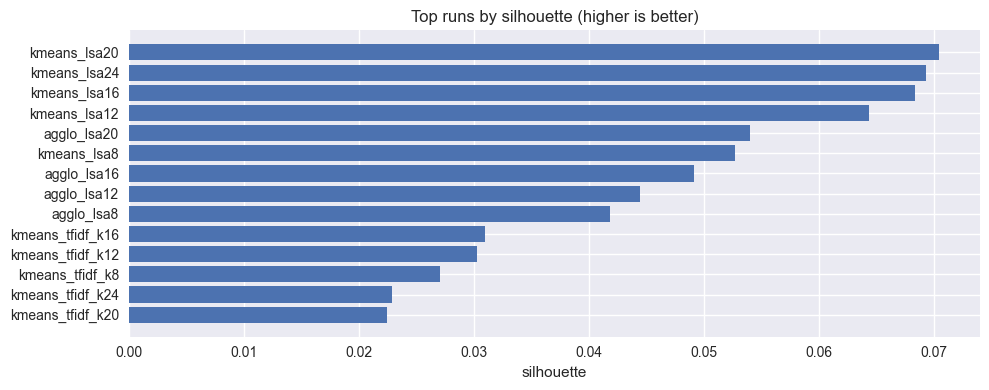

In [7]:
fig, ax = plt.subplots(1, 1, figsize=(10, 4))
tmp = res_df.dropna(subset=["silhouette"]).sort_values("silhouette", ascending=False).head(15)
ax.barh(tmp["name"], tmp["silhouette"], color="#4C72B0")
ax.invert_yaxis()
ax.set_title("Top runs by silhouette (higher is better)")
ax.set_xlabel("silhouette")
plt.tight_layout()
save_current_fig("model_top_silhouette.png")
plt.show()


## 4) Choose a candidate model

We pick a candidate run combining metrics + cluster size balance + interpretability.
As a defendable baseline, we pick the best silhouette among KMeans/LSA runs.


In [8]:
best_row = (
    res_df[res_df["name"].str.startswith("kmeans_lsa")]
    .sort_values("silhouette", ascending=False)
    .iloc[0]
)
best_row


name                                              kmeans_lsa20
n_clusters                                                  20
noise_rate                                                 0.0
silhouette                                            0.070455
calinski_harabasz                                    14.080045
davies_bouldin                                        3.254502
top_cluster_sizes    [101, 77, 68, 65, 61, 61, 61, 58, 50, 47]
Name: 8, dtype: object

In [9]:
best_name = str(best_row["name"])
best_k = int(best_name.replace("kmeans_lsa", ""))
best_model = KMeans(n_clusters=best_k, n_init=20, random_state=42)
best_labels = best_model.fit_predict(X_lsa)
best_labels[:10], best_k


(array([ 0, 11, 13, 11,  9, 11, 15, 19, 15, 19], dtype=int32), 20)

### Cluster size balance


In [10]:
sizes = pd.Series(best_labels).value_counts().sort_index()
sizes


0      68
1      23
2      61
3      65
4      47
5      77
6      28
7      35
8      45
9      45
10     61
11     58
12     25
13    101
14     28
15     61
16     42
17     50
18     43
19     32
Name: count, dtype: int64

Saved: figures/model_cluster_sizes.png


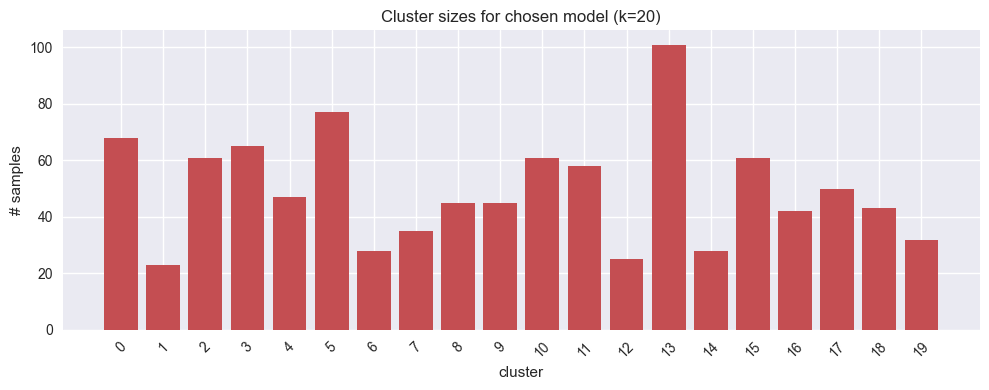

In [11]:
fig, ax = plt.subplots(1, 1, figsize=(10, 4))
ax.bar(sizes.index.astype(str), sizes.values, color="#C44E52")
ax.set_title(f"Cluster sizes for chosen model (k={best_k})")
ax.set_xlabel("cluster")
ax.set_ylabel("# samples")
plt.xticks(rotation=45)
plt.tight_layout()
save_current_fig("model_cluster_sizes.png")
plt.show()


## 5) Interpretability: top terms and representative examples

We extract:
- top TF-IDF terms per cluster (for naming/intuition)
- a few representative testimonies per cluster (closest to centroid)


In [12]:
km_tfidf = KMeans(n_clusters=best_k, n_init=20, random_state=42)
labels_tfidf = km_tfidf.fit_predict(X_tfidf)

feature_names = np.array(tfidf.get_feature_names_out())
top_n = 10

top_terms = {}
for c in range(best_k):
    centroid = km_tfidf.cluster_centers_[c]
    top_idx = np.argsort(centroid)[::-1][:top_n]
    top_terms[c] = feature_names[top_idx].tolist()

pd.DataFrame({"cluster": list(top_terms.keys()), "top_terms": list(top_terms.values())}).head()


,cluster,top_terms
0,0,"[blood, blood pressure, pressure, feel, doctor..."
1,1,"[nose, felt, throat, runny, mild, runny nose, ..."
2,2,"[deep, deep breath, breath, walking, sharp, ch..."
3,3,"[ear, ear hurts, hear, hurts, slight, right ea..."
4,4,"[chest, tight, feels tight, chest feels, feels..."


In [13]:
df_out = df[["id", "color", "testimony_raw", "testimony_clean"]].copy()
df_out["cluster"] = best_labels

centroids_lsa = np.vstack([X_lsa[best_labels == c].mean(axis=0) for c in range(best_k)])

def closest_examples(cluster_id: int, n: int = 3) -> pd.DataFrame:
    idx = np.where(best_labels == cluster_id)[0]
    if idx.size == 0:
        return df_out.iloc[0:0]
    pts = X_lsa[idx]
    c = centroids_lsa[cluster_id]
    dists = np.linalg.norm(pts - c, axis=1)
    pick = idx[np.argsort(dists)[:n]]
    return df_out.loc[pick, ["id", "testimony_raw"]]

for c in range(min(5, best_k)):
    print(f"Cluster {c} top terms: {top_terms.get(c, [])}")
    display(closest_examples(c, n=3))


Cluster 0 top terms: ['blood', 'blood pressure', 'pressure', 'feel', 'doctor', 'high', 'vision', 'tingling', 'feet', 'told']


,id,testimony_raw
716,726,"A deep, dry cough leaves me short of breath af..."
562,568,Mornings start with several coughs to clear th...
98,100,"On flat ground I’m okay, but a single flight o..."


Cluster 1 top terms: ['nose', 'felt', 'throat', 'runny', 'mild', 'runny nose', 'day', 'took', 'headache', 'congestion']


,id,testimony_raw
538,544,I feel faint and my skin turns pale when I sta...
235,237,"I keep feeling lightheaded, and my skin is pal..."
405,409,I keep feeling faint and my skin looks pale. I...


Cluster 2 top terms: ['deep', 'deep breath', 'breath', 'walking', 'sharp', 'chest', 'makes', 'pain', 'breathless', 'room']


,id,testimony_raw
825,838,I felt a slight sore throat and a runny nose t...
155,157,I got a cold after a rainy day at the office. ...
52,54,I experienced a sudden onset of sneezing and a...


Cluster 3 top terms: ['ear', 'ear hurts', 'hear', 'hurts', 'slight', 'right ear', 'sound', 'child', 'buzzing', 'faint']


,id,testimony_raw
886,901,I've been having this throbbing pain that star...
463,469,I keep having this throbbing pain that starts ...
343,347,"Every time I get a headache, I feel a throbbin..."


Cluster 4 top terms: ['chest', 'tight', 'feels tight', 'chest feels', 'feels', 'tightness', 'short', 'just', 'pressure', 'feel']


,id,testimony_raw
753,764,Rolling the ankle inward made the inner side s...
908,923,"After a long walk, the inside of my ankle ache..."
635,644,I twisted my foot stepping off a curb; the out...


## 6) Required plots: clusters vs hidden `color`

We project the TF-IDF space into 2D using SVD and plot:
- points colored by **cluster**
- points colored by hidden **color** (viz-only)


Saved: figures/2d_projection_colored_by_cluster_k20.png


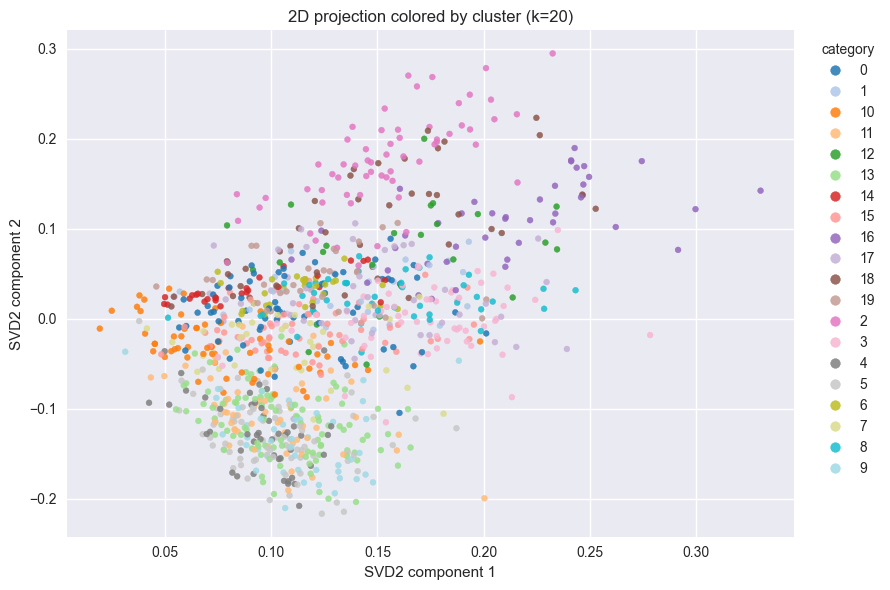

Saved: figures/2d_projection_colored_by_hidden_color_viz_only.png


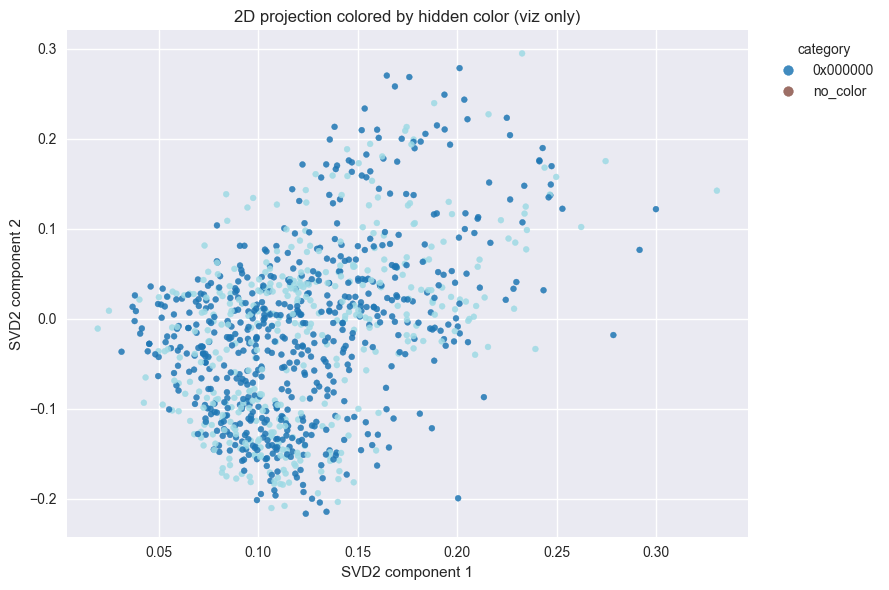

In [14]:
svd2 = TruncatedSVD(n_components=2, random_state=42)
X_2d = svd2.fit_transform(X_tfidf)

def scatter_by(values, title: str, *, s: int = 18):
    fig, ax = plt.subplots(1, 1, figsize=(9, 6))
    vals = pd.Series(values).astype(str).fillna("None")
    uniq = vals.nunique()

    if uniq <= 25:
        cats = vals.astype("category")
        sc = ax.scatter(X_2d[:, 0], X_2d[:, 1], c=cats.cat.codes, cmap="tab20", s=s, alpha=0.85)
        handles, _ = sc.legend_elements(num=min(uniq, 20))
        ax.legend(handles, list(cats.cat.categories)[: len(handles)], title="category", bbox_to_anchor=(1.02, 1), loc="upper left")
    else:
        codes = vals.astype("category").cat.codes
        ax.scatter(X_2d[:, 0], X_2d[:, 1], c=codes, cmap="viridis", s=s, alpha=0.85)

    ax.set_title(title)
    ax.set_xlabel("SVD2 component 1")
    ax.set_ylabel("SVD2 component 2")
    plt.tight_layout()
    # Save a stable filename derived from the title
    safe = (
        title.lower()
        .replace(" ", "_")
        .replace("=", "")
        .replace("(", "")
        .replace(")", "")
        .replace("/", "_")
    )
    save_current_fig(f"{safe}.png")
    plt.show()

scatter_by(best_labels, f"2D projection colored by cluster (k={best_k})")
scatter_by(df_out["color"].fillna("no_color"), "2D projection colored by hidden color (viz only)")


## 7) Save clustering output

We export a file for later use / defense: `id`, `cluster`, `color` (viz-only), and `testimony_raw`.


In [15]:
CLUSTERS_PATH = Path("unsupervised_clusters.csv")
df_save = df_out[["id", "cluster", "color", "testimony_raw"]].copy()
df_save.to_csv(CLUSTERS_PATH, index=False)
CLUSTERS_PATH.resolve()


PosixPath('/Users/karma/code/epitech/2_year/G-AIA-400-LYN-4-1-cvrie-3/unsupervised/unsupervised_clusters.csv')